# Auto-Tagging Images with Cohere Embed 4 on Microsoft Foundry

This notebook demonstrates how to use **Cohere Embed v4** (deployed via **Microsoft Foundry**) to automatically tag images using multimodal embeddings.

**Approach:**
1. Define a set of candidate tags as text
2. Embed both images and tags into the same vector space
3. Compute cosine similarity to assign the most relevant tags

**Prerequisites:**
- Azure AI Foundry endpoint with Cohere Embed v4 deployed
- `azure-ai-inference` and `azure-identity` packages
- Python 3.10+


In [1]:
import base64
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
import sys

from azure.ai.inference import EmbeddingsClient, ImageEmbeddingsClient
from azure.ai.inference.models import ImageEmbeddingInput, EmbeddingInputType
from azure.core.credentials import AzureKeyCredential
from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
from PIL import Image

In [2]:
sys.version

'3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]'

In [3]:
print(f"Today is {datetime.datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 16-Feb-2026 11:33:15


## 1. Helper

In [4]:
def download_image(url: str, timeout: int = 10) -> Image.Image | None:
    """Download an image from URL and return as PIL Image."""
    try:
        response = requests.get(url, timeout=timeout)
        response.raise_for_status()
        
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        
        return None

In [5]:
def image_to_base64(img: Image.Image, max_size: int = 512) -> str:
    """Convert PIL Image to base64 string, resizing if needed."""
    # Resize to limit token usage
    img.thumbnail((max_size, max_size), Image.LANCZOS)
    buffer = BytesIO()
    img.save(buffer, format="JPEG", quality=85)
    
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

In [6]:
def cosine_similarity_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Compute cosine similarity between all pairs of rows in A and B."""
    A_norm = A / np.linalg.norm(A, axis=1, keepdims=True)
    B_norm = B / np.linalg.norm(B, axis=1, keepdims=True)
    
    return A_norm @ B_norm.T

In [7]:
def auto_tagging(
        image_embedding: np.ndarray,
        tag_embeddings: np.ndarray,
        tags: list[str],
        tag_to_facet: dict[str, str],
        top_per_facet: int = 1,
        threshold: float = 0.15) -> dict[str, list[tuple[str, float]]]:
    """
    Assign tags to an image by picking the best match per facet.
    
    Returns dict: {facet: [(tag, score), ...]}
    """
    # Compute similarities
    similarities = cosine_similarity_matrix(image_embedding.reshape(1, -1),
                                            tag_embeddings).flatten()

    # Group by facet and pick top matches
    results = {}
    facets = set(tag_to_facet.values())

    for facet in facets:
        facet_indices = [
            i for i, t in enumerate(tags) if tag_to_facet[t] == facet
        ]
        facet_scores = [(tags[i], similarities[i]) for i in facet_indices]
        facet_scores.sort(key=lambda x: x[1], reverse=True)

        # Apply threshold and take top N
        top = [(tag, score) for tag, score in facet_scores[:top_per_facet]
               if score >= threshold]
        if top:
            results[facet] = top

    return results

## 2. Configuration

Update the endpoint below with your Azure AI Foundry deployment details.


In [8]:
load_dotenv("azure.env")

MODEL_NAME = "embed-v-4-0"
EMBEDDING_DIMENSIONS = 1536

In [9]:
cred = DefaultAzureCredential()
tok = cred.get_token("https://cognitiveservices.azure.com/.default")

image_client = ImageEmbeddingsClient(
    endpoint=os.getenv("endpoint"),
    credential=AzureKeyCredential(tok.token),
    model=MODEL_NAME,
    output_dimension=EMBEDDING_DIMENSIONS,  # 1536, 1024, 768, 512, 256
    embedding_types=["float"],  # float, int8, unint8, binary, ubinary
)

In [10]:
cred = DefaultAzureCredential()
tok = cred.get_token("https://cognitiveservices.azure.com/.default")

text_client = EmbeddingsClient(
    endpoint=os.getenv("endpoint"),
    credential=AzureKeyCredential(tok.token),
    model=MODEL_NAME,
    output_dimension=1536,  # 1536, 1024, 768, 512, 256
    embedding_types=["float"],  # float, int8, unint8, binary, ubinary
)

## 3. Sample Images

We'll use freely available sample images for demonstration. In production, these would be your product catalog images.


In [11]:
SAMPLE_IMAGES = {
    "red_dress": {
        "url":
        "https://i.etsystatic.com/20151049/r/il/0e843d/1886021212/il_1588xN.1886021212_qgcu.jpg",
        "description": "Red dress"
    },
    "denim_jacket": {
        "url":
        "https://media.vogue.fr/photos/620baf08ac49caf24d57d9bf/master/w_1280%2Cc_limit/levis.jpg",
        "description": "Denim jacket"
    },
    "sneakers": {
        "url":
        "https://www.labonnepointure.fr/cache/images/product/img_3752.jpg-121762.jpg",
        "description": "Red sneakers"
    },
    "sunglasses": {
        "url":
        "https://d237xocrarx9cy.cloudfront.net/image/foto//luxottica/0RB2140%20901.jpg",
        "description": "Sunglasses"
    },
    "leather_bag": {
        "url":
        "https://images.unsplash.com/photo-1548036328-c9fa89d128fa?w=400",
        "description": "Leather bag"
    },
    "winter_coat": {
        "url":
        "https://images.unsplash.com/photo-1539533018447-63fcce2678e3?w=400",
        "description": "Winter coat"
    }
}

In [12]:
SAMPLE_IMAGES

{'red_dress': {'url': 'https://i.etsystatic.com/20151049/r/il/0e843d/1886021212/il_1588xN.1886021212_qgcu.jpg',
  'description': 'Red dress'},
 'denim_jacket': {'url': 'https://media.vogue.fr/photos/620baf08ac49caf24d57d9bf/master/w_1280%2Cc_limit/levis.jpg',
  'description': 'Denim jacket'},
 'sneakers': {'url': 'https://www.labonnepointure.fr/cache/images/product/img_3752.jpg-121762.jpg',
  'description': 'Red sneakers'},
 'sunglasses': {'url': 'https://d237xocrarx9cy.cloudfront.net/image/foto//luxottica/0RB2140%20901.jpg',
  'description': 'Sunglasses'},
 'leather_bag': {'url': 'https://images.unsplash.com/photo-1548036328-c9fa89d128fa?w=400',
  'description': 'Leather bag'},
 'winter_coat': {'url': 'https://images.unsplash.com/photo-1539533018447-63fcce2678e3?w=400',
  'description': 'Winter coat'}}

In [13]:
images = {}

for name, info in SAMPLE_IMAGES.items():
    img = download_image(info["url"])
    if img:
        images[name] = {
            "image": img,
            "base64": image_to_base64(img),
            "description": info["description"]
        }
        print(f"✅ {name}: {info['description']} ({img.size[0]}x{img.size[1]})")
    else:
        print(f"❌ {name}: Failed to download")

print(f"\n📸 Successfully loaded {len(images)} / {len(SAMPLE_IMAGES)} images")

✅ red_dress: Red dress (341x512)
✅ denim_jacket: Denim jacket (355x512)
✅ sneakers: Red sneakers (512x384)
✅ sunglasses: Sunglasses (512x256)
✅ leather_bag: Leather bag (400x267)
✅ winter_coat: Winter coat (341x512)

📸 Successfully loaded 6 / 6 images


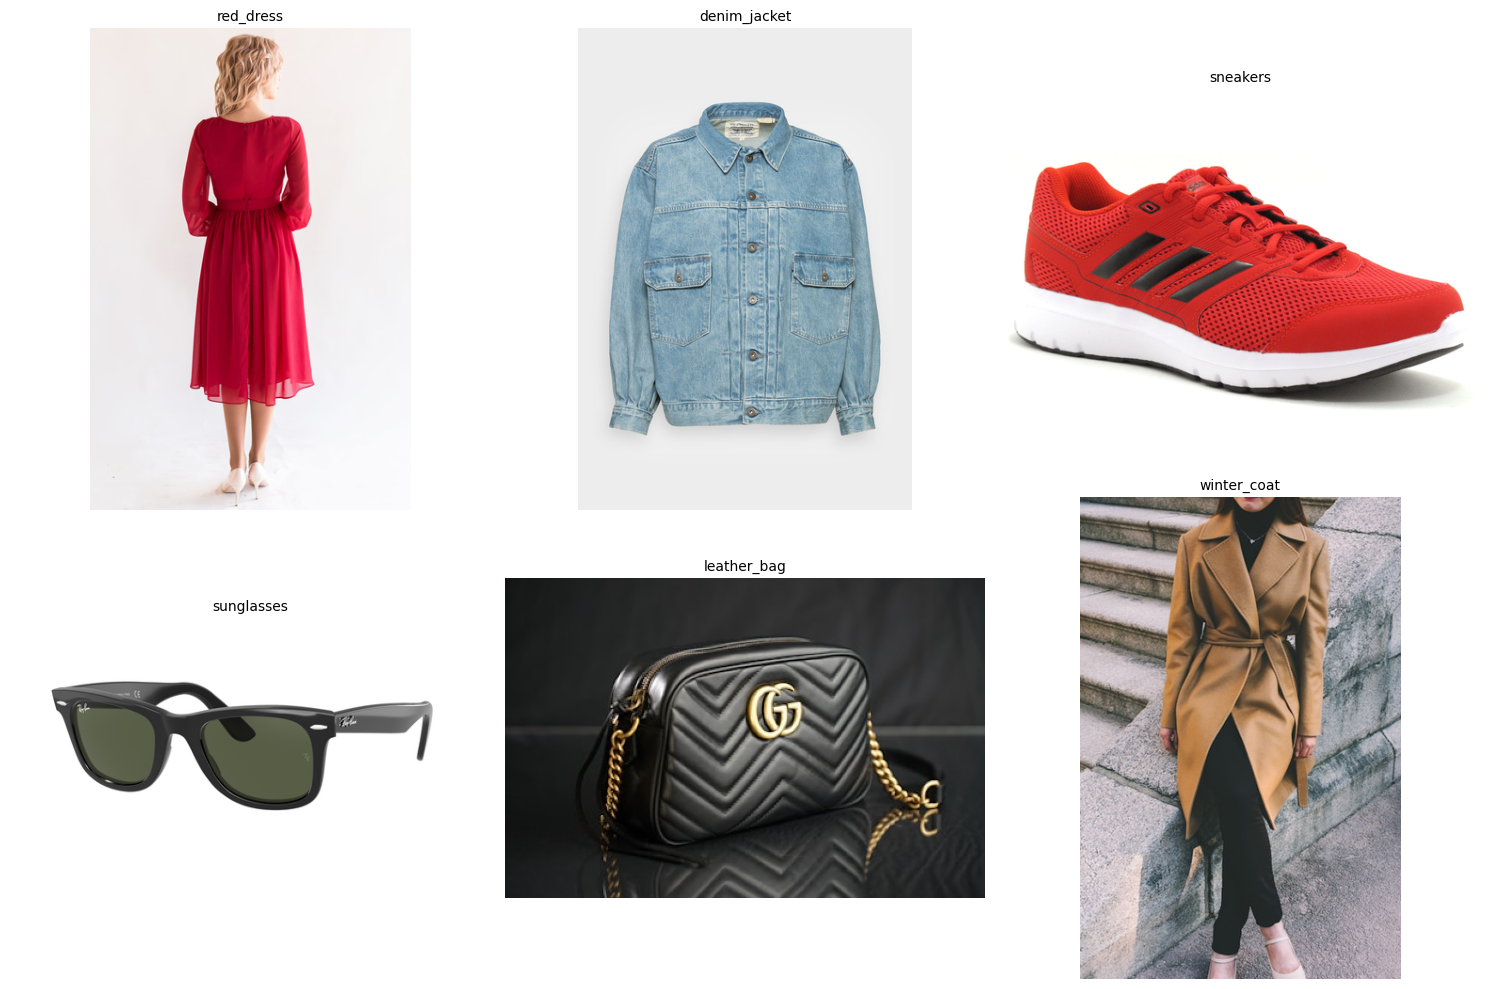

In [14]:
cols = 3
rows = (len(images) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

for i, (name, data) in enumerate(images.items()):
    axes[i].imshow(data["image"])
    axes[i].set_title(name, fontsize=10)
    axes[i].axis("off")

for j in range(len(images), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 4. Define Candidate Tags

We organize tags into **facets** (category, color, material, pattern, season, style). This allows us to pick the best tag per facet for structured metadata.


In [15]:
TAG_FACETS = {
    "category": [
        "dress", "jacket", "coat", "blouse", "shirt", "t-shirt", "pants",
        "jeans", "skirt", "shoes", "sneakers", "boots", "handbag", "backpack",
        "hat", "scarf", "accessories", "sunglasses"
    ],
    "color": [
        "red", "blue", "black", "white", "green", "yellow", "pink", "brown",
        "beige", "grey", "navy", "multicolor"
    ],
    "material": [
        "leather", "denim", "cotton", "silk", "wool", "polyester", "suede",
        "canvas", "linen", "synthetic", "glass"
    ],
    "pattern": [
        "solid color", "floral pattern", "striped", "plaid", "polka dot",
        "geometric", "animal print", "plain"
    ],
    "season": [
        "spring outfit", "summer outfit", "autumn outfit", "winter outfit",
        "all-season"
    ],
    "style": [
        "casual wear", "formal wear", "sporty", "elegant", "bohemian",
        "streetwear", "vintage", "minimalist"
    ]
}

In [16]:
TAG_FACETS

{'category': ['dress',
  'jacket',
  'coat',
  'blouse',
  'shirt',
  't-shirt',
  'pants',
  'jeans',
  'skirt',
  'shoes',
  'sneakers',
  'boots',
  'handbag',
  'backpack',
  'hat',
  'scarf',
  'accessories',
  'sunglasses'],
 'color': ['red',
  'blue',
  'black',
  'white',
  'green',
  'yellow',
  'pink',
  'brown',
  'beige',
  'grey',
  'navy',
  'multicolor'],
 'material': ['leather',
  'denim',
  'cotton',
  'silk',
  'wool',
  'polyester',
  'suede',
  'canvas',
  'linen',
  'synthetic',
  'glass'],
 'pattern': ['solid color',
  'floral pattern',
  'striped',
  'plaid',
  'polka dot',
  'geometric',
  'animal print',
  'plain'],
 'season': ['spring outfit',
  'summer outfit',
  'autumn outfit',
  'winter outfit',
  'all-season'],
 'style': ['casual wear',
  'formal wear',
  'sporty',
  'elegant',
  'bohemian',
  'streetwear',
  'vintage',
  'minimalist']}

In [17]:
all_tags = []
tag_to_facet = {}

for facet, tags in TAG_FACETS.items():
    for tag in tags:
        all_tags.append(tag)
        tag_to_facet[tag] = facet

print(f"Total tags = {len(all_tags)} across {len(TAG_FACETS)} facets:")

for facet, tags in TAG_FACETS.items():
    print(f"   {facet:10} = {len(tags)} tags")

Total tags = 62 across 6 facets:
   category   = 18 tags
   color      = 12 tags
   material   = 11 tags
   pattern    = 8 tags
   season     = 5 tags
   style      = 8 tags


## 5. Generate Embeddings

### 5.1 Embed all candidate tags (text)


In [18]:
tag_response = text_client.embed(input=all_tags, )

tag_embeddings = np.array([item.embedding for item in tag_response.data])
print(f"Tag embeddings shape: {tag_embeddings.shape}")
print(f"Embedding dimension: {tag_embeddings.shape[1]}")

Tag embeddings shape: (62, 1536)
Embedding dimension: 1536


### 5.2 Embed all images

In [19]:
image_inputs = [{
    "image": f"data:image/jpeg;base64,{data['base64']}"
} for data in images.values()]

image_response = image_client.embed(input=image_inputs, )

image_embeddings = np.array([item.embedding for item in image_response.data])
image_names = list(images.keys())
print(f"Image embeddings shape: {image_embeddings.shape}")
print(f"Embedding dimension: {image_embeddings.shape[1]}")

Image embeddings shape: (6, 1536)
Embedding dimension: 1536


## 6. Auto-Tagging Engine

In [20]:
all_results = {}

for i, name in enumerate(image_names):
    tags_result = auto_tagging(image_embeddings[i],
                                 tag_embeddings,
                                 all_tags,
                                 tag_to_facet,
                                 top_per_facet=2,
                                 threshold=0.10)
    
    all_results[name] = tags_result

# Display results
for name, tags_result in all_results.items():
    desc = images[name]["description"]
    print(f"\n{'='*100}")
    print(f"📸 {desc} ({name})")
    print(f"{'='*100}")
    for facet, tag_scores in sorted(tags_result.items()):
        tags_str = ", ".join([f"{t} (score = {s:.3f})" for t, s in tag_scores])
        print(f"   - {facet} = {tags_str}")


📸 Red dress (red_dress)
   - category = dress (score = 0.461), skirt (score = 0.311)
   - color = red (score = 0.316), pink (score = 0.216)
   - material = linen (score = 0.280), polyester (score = 0.262)
   - pattern = solid color (score = 0.290), plain (score = 0.265)
   - season = spring outfit (score = 0.304), autumn outfit (score = 0.283)
   - style = formal wear (score = 0.368), bohemian (score = 0.310)

📸 Denim jacket (denim_jacket)
   - category = jacket (score = 0.398), jeans (score = 0.334)
   - color = blue (score = 0.268), grey (score = 0.193)
   - material = denim (score = 0.425), suede (score = 0.259)
   - pattern = plaid (score = 0.230), solid color (score = 0.193)
   - season = autumn outfit (score = 0.179), winter outfit (score = 0.175)
   - style = streetwear (score = 0.258), casual wear (score = 0.255)

📸 Red sneakers (sneakers)
   - category = shoes (score = 0.327), sneakers (score = 0.322)
   - color = red (score = 0.331), yellow (score = 0.229)
   - material = sy

In [21]:
rows_long = []

for name, tags_result in all_results.items():
    for facet, tag_scores in tags_result.items():
        for rank, (tag, score) in enumerate(tag_scores, 1):
            rows_long.append({
                "image_name": name,
                "description": images[name]["description"],
                "facet": facet,
                "rank": rank,
                "tag": tag,
                "score": round(score, 4)
            })

df = pd.DataFrame(rows_long)
df

,image_name,description,facet,rank,tag,score
0,red_dress,Red dress,material,1,linen,0.2799
1,red_dress,Red dress,material,2,polyester,0.2618
2,red_dress,Red dress,pattern,1,solid color,0.2900
3,red_dress,Red dress,pattern,2,plain,0.2651
4,red_dress,Red dress,style,1,formal wear,0.3677
...,...,...,...,...,...,...
67,winter_coat,Winter coat,season,2,winter outfit,0.3852
68,winter_coat,Winter coat,color,1,beige,0.3049
69,winter_coat,Winter coat,color,2,brown,0.2862
70,winter_coat,Winter coat,category,1,coat,0.3786


In [22]:
pivot = df[df["rank"] == 1].pivot_table(
    index=["image_name", "description"],
    columns="facet",
    values="tag",
    aggfunc="first"
)

pivot

,facet,category,color,material,pattern,season,style
image_name,description,,,,,,
denim_jacket,Denim jacket,jacket,blue,denim,plaid,autumn outfit,streetwear
leather_bag,Leather bag,handbag,black,leather,plaid,all-season,elegant
red_dress,Red dress,dress,red,linen,solid color,spring outfit,formal wear
sneakers,Red sneakers,shoes,red,synthetic,solid color,all-season,sporty
sunglasses,Sunglasses,sunglasses,green,glass,geometric,all-season,minimalist
winter_coat,Winter coat,coat,beige,wool,solid color,autumn outfit,formal wear


## 7. Visualize Results

Display each image with its auto-generated tags.


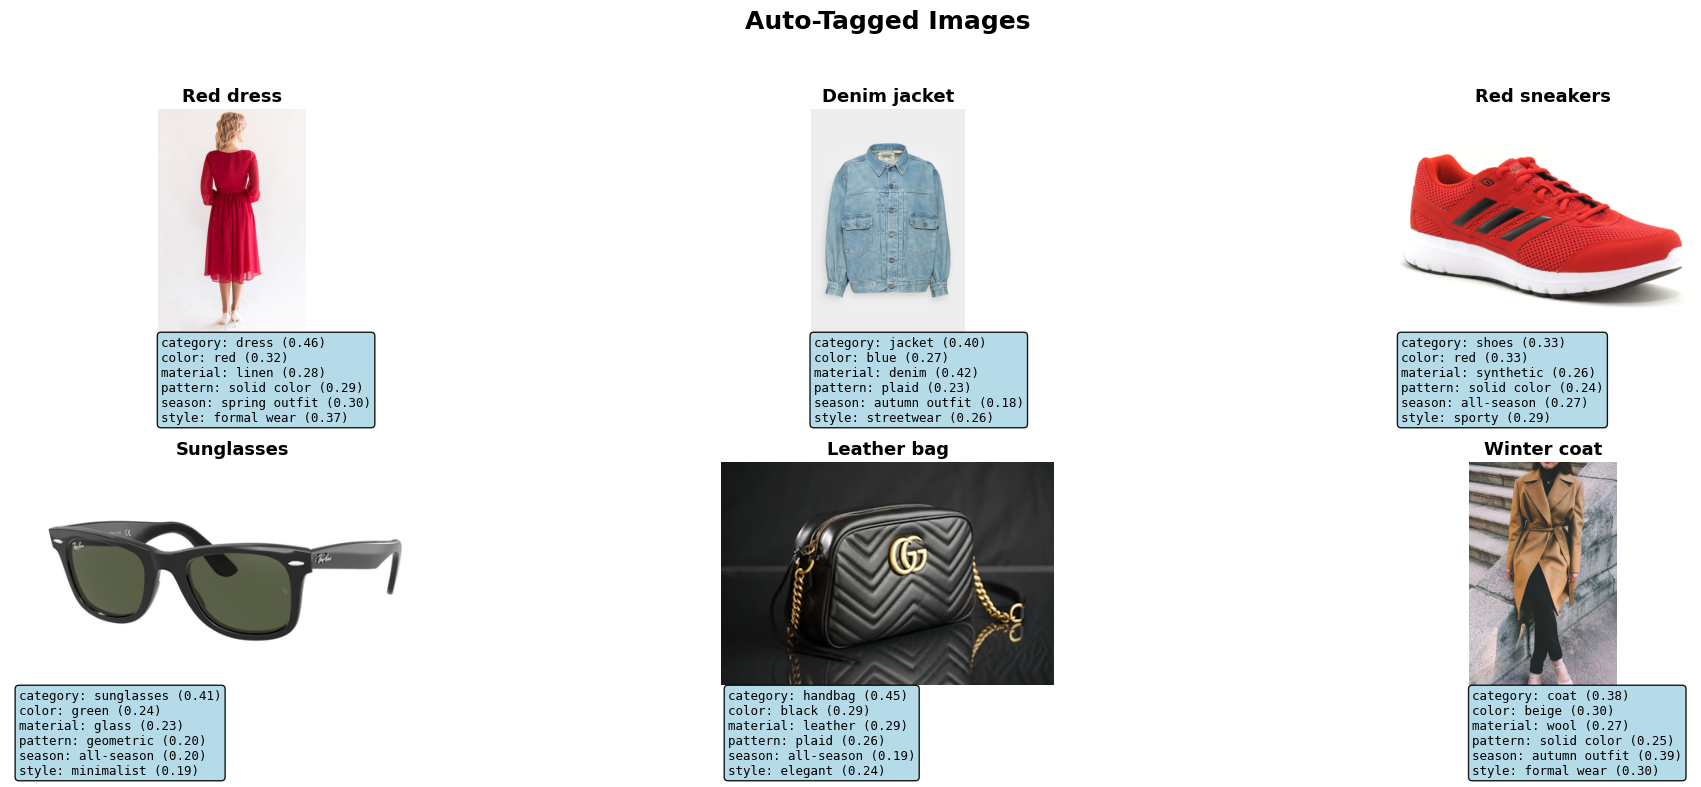

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle("Auto-Tagged Images", fontsize=18, fontweight="bold", y=0.98)

for ax, (name, data) in zip(axes.flat, images.items()):
    ax.imshow(data["image"])
    # Build tag string
    tags_result = all_results.get(name, {})
    tag_lines = []
    for facet in [
            "category", "color", "material", "pattern", "season", "style"
    ]:
        if facet in tags_result:
            best_tag, score = tags_result[facet][0]
            tag_lines.append(f"{facet}: {best_tag} ({score:.2f})")

    tag_text = "\n".join(tag_lines) if tag_lines else "No tags assigned"

    ax.set_title(data["description"], fontsize=13, fontweight="bold")
    ax.text(0.02,
            -0.02,
            tag_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="lightblue",
                      alpha=0.9))
    ax.axis("off")

for ax in axes.flat[len(images):]:
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 8. Similarity Heatmap

Visualize how each image relates to every tag across all facets.


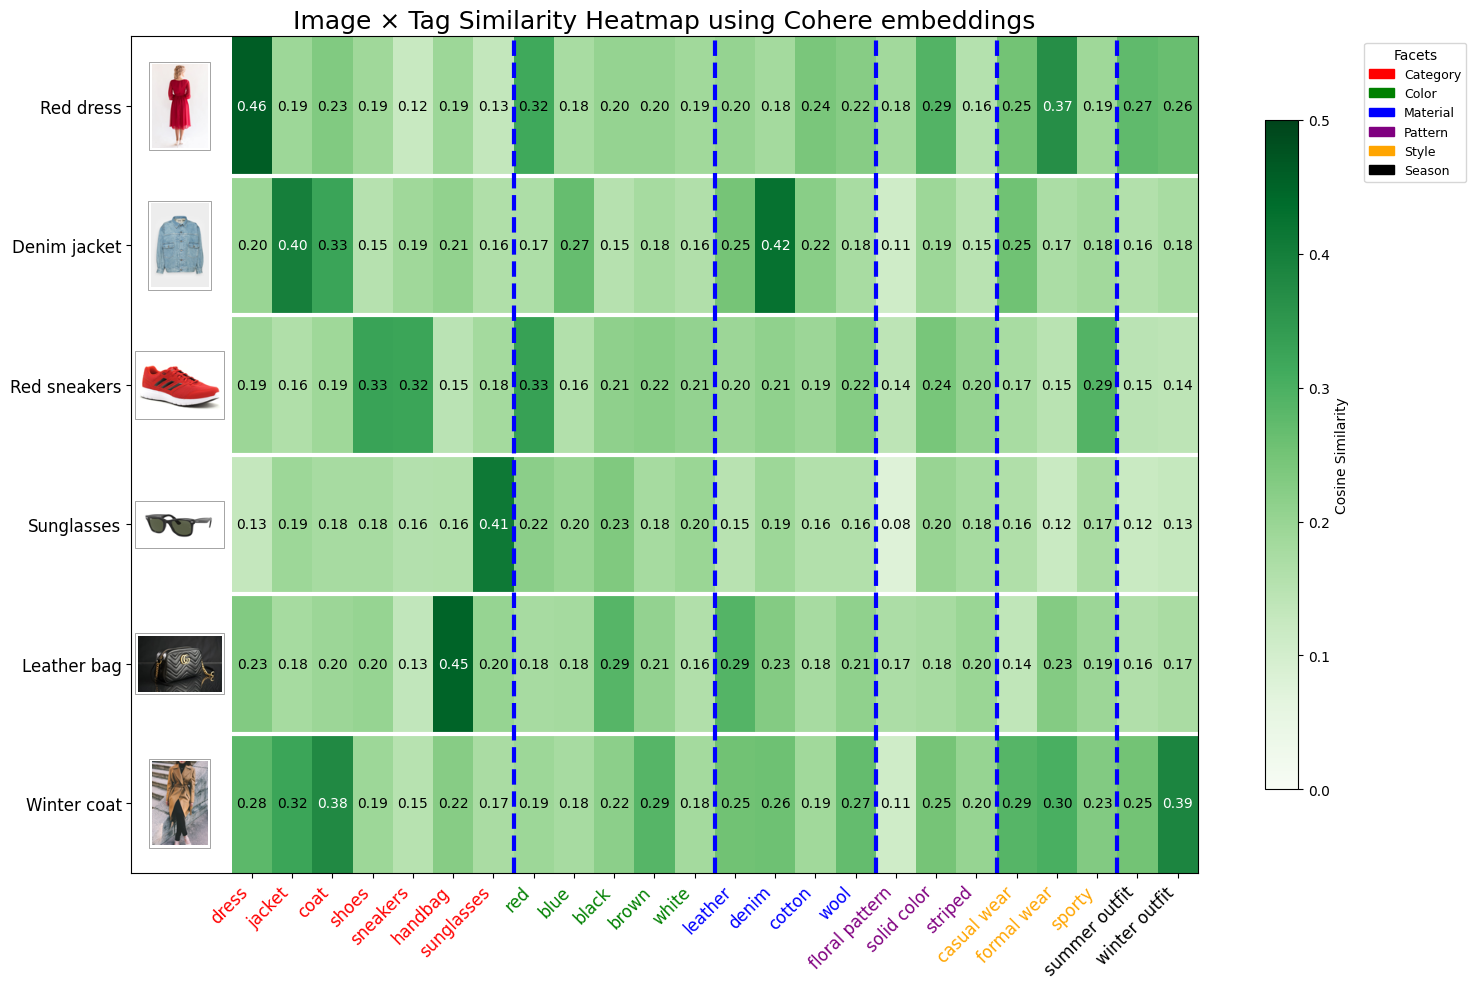

In [24]:
tag_to_group = {}

for t in ["dress", "jacket", "coat", "shoes", "sneakers", "handbag", "sunglasses"]:
    tag_to_group[t] = "Category"
for t in ["red", "blue", "black", "brown", "white"]:
    tag_to_group[t] = "Color"
for t in ["leather", "denim", "cotton", "wool"]:
    tag_to_group[t] = "Material"
for t in ["floral pattern", "solid color", "striped"]:
    tag_to_group[t] = "Pattern"
for t in ["casual wear", "formal wear", "sporty"]:
    tag_to_group[t] = "Style"
for t in ["summer outfit", "winter outfit"]:
    tag_to_group[t] = "Season"

facet_colors = {
    "Category": "red", "Color": "green", "Material": "blue",
    "Pattern": "purple",  "Style": "orange",  "Season": "black"
}

selected_tags = [
    "dress", "jacket", "coat", "shoes", "sneakers", "handbag", "sunglasses",
    "red", "blue", "black", "brown", "white",
    "leather", "denim", "cotton", "wool", "floral pattern", "solid color", "striped", 
    "casual wear", "formal wear",
    "sporty", "summer outfit", "winter outfit", 
]

selected_indices = [all_tags.index(t) for t in selected_tags if t in all_tags]
selected_tag_embeddings = tag_embeddings[selected_indices]
selected_tag_names = [all_tags[i] for i in selected_indices]

sim_matrix = cosine_similarity_matrix(image_embeddings, selected_tag_embeddings)

fig, ax = plt.subplots(figsize=(15, 10))
im = ax.imshow(sim_matrix, cmap="Greens", aspect="auto", vmin=0, vmax=0.5)
ax.set_xticks(range(len(selected_tag_names)))
xlabels = ax.set_xticklabels(selected_tag_names, rotation=45, ha="right", fontsize=12)

# Color x-labels by facet
for label in xlabels:
    tag = label.get_text()
    if tag in tag_to_group:
        label.set_color(facet_colors[tag_to_group[tag]])

ax.set_yticks(range(len(image_names)))
ax.set_yticklabels([images[n]["description"] for n in image_names], fontsize=12)

for i in range(len(image_names)):
    for j in range(len(selected_tag_names)):
        val = sim_matrix[i, j]
        color = "white" if val > 0.35 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=color)

# Facet separator lines
prev_group = None
for j, tag in enumerate(selected_tag_names):
    curr_group = tag_to_group.get(tag)
    if prev_group and curr_group != prev_group:
        ax.axvline(x=j - 0.5, color="blue", linewidth=3, linestyle="--")
    prev_group = curr_group

plt.colorbar(im, ax=ax, label="Cosine Similarity", shrink=0.8)
ax.set_title("Image × Tag Similarity Heatmap using Cohere embeddings", fontsize=18)

# Facet legend
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in facet_colors.items()]
ax.legend(handles=legend_patches, loc="upper left", bbox_to_anchor=(1.15, 1.0),
          fontsize=9, title="Facets", title_fontsize=10)

ax.set_yticks([i - 0.5 for i in range(1, len(image_names))], minor=True)
ax.grid(which="minor", axis="y", color="white", linewidth=3)
ax.tick_params(which="minor", size=0)

for i, name in enumerate(image_names):
    img = images[name]["image"].copy()
    img.thumbnail((100, 100))  # small thumbnail
    im_arr = np.array(img)
    imagebox = OffsetImage(im_arr, zoom=0.6)
    ab = AnnotationBbox(imagebox, (-1.8, i), frameon=True,
                        xycoords="data", boxcoords="data",
                        pad=0.2, bboxprops=dict(edgecolor="gray", linewidth=0.5))
    ax.add_artist(ab)

# Expand left margin to make room for thumbnails
ax.set_xlim(-3, len(selected_tag_names) - 0.5)

plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()